# Exploración de Operadores y el Teorema "No Free Lunch"

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/05_algoritmos_geneticos/02_operadores_y_benchmarks.ipynb)

## Objetivos


- Comprender el Teorema *No Free Lunch* y la necesidad de utilizar funciones de *benchmark* estandarizadas en ingeniería.
- Analizar visual y matemáticamente paisajes de fitness complejos (Rastrigin, Ackley, Schwefel).
- Comparar el comportamiento y la presión selectiva de distintos operadores de selección y cruce.
- Diagnosticar la convergencia prematura y realizar un análisis de sensibilidad de hiperparámetros mediante mapas de calor (*heatmaps*).



## Prerrequisitos


- Haber completado: [El Algoritmo Genético desde Cero](01_algoritmo_genetico_desde_cero.ipynb).
- Comprensión de la mecánica básica evolutiva (población, selección, cruce, mutación).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Fijamos la semilla para reproducibilidad
SEED = 42
rng = np.random.default_rng(SEED)

## Introducción Teórica



En el notebook anterior, resolvimos un problema 1D sencillo. Pero en la vida real, ¿cómo sabemos si nuestro Algoritmo Genético (GA) es realmente bueno? ¿Cómo comparamos dos configuraciones distintas?

Aquí entra en juego el **Teorema "No Free Lunch" (NFL)** de Wolpert y Macready (1997). En términos simples, el teorema establece que *si promediamos el rendimiento de cualquier algoritmo de optimización sobre todos los problemas posibles, su rendimiento será idéntico al de una búsqueda puramente aleatoria*.

**¿Qué significa esto para nosotros?**
Significa que **no existe un algoritmo universalmente superior**. Un GA configurado de cierta manera puede ser excelente para diseñar el ala de un avión, pero pésimo para optimizar los pesos de una red neuronal.

Por lo tanto, para evaluar la robustez de nuestros algoritmos, la comunidad científica ha diseñado **Funciones de *Benchmark***. Estas funciones son "pistas de obstáculos" matemáticas diseñadas específicamente para engañar, atrapar o confundir a los algoritmos de optimización.


## Desarrollo e Implementación


### 1. Funciones de *Benchmark* Clásicas



A diferencia de los problemas académicos simples, estas funciones evalúan debilidades específicas del algoritmo, a continuación, abordamos algunas de ellas.


#### 1.1 Función de Rastrigin (Evaluación de Multimodalidad)


Es una función no lineal que produce un paisaje lleno de "pozos" regulares (la pesadilla de los algoritmos basados en gradiente). Evalúa la capacidad del algoritmo para escapar de una inmensa cantidad de óptimos locales.

$$f(\mathbf{x}) = 10D + \sum_{i=1}^{D} \left[ x_i^2 - 10\cos(2\pi x_i) \right]$$

* **Mínimo global:** $f(\mathbf{x}) = 0$ en $\mathbf{x} = (0, 0, \dots, 0)$.
* **Dominio típico:** $[-5.12, 5.12]$.

#### 1.2 Función de Ackley (Evaluación de Zonas Planas)


Combina un término exponencial con un término de coseno. Su característica principal es que es casi plana en los bordes (gradiente casi nulo), pero tiene un agujero muy estrecho y profundo en el centro. Evalúa si el algoritmo puede moverse cuando no hay una pendiente clara que seguir.


$$f(\mathbf{x}) = -20 \exp\left(-0.2 \sqrt{\frac{1}{D} \sum_{i=1}^{D} x_i^2}\right) - \exp\left(\frac{1}{D} \sum_{i=1}^{D} \cos(2\pi x_i)\right) + 20 + e$$

* **Mínimo global:** $f(\mathbf{x}) = 0$ en $\mathbf{x} = (0, 0, \dots, 0)$.
* **Dominio típico:** $[-32, 32]$.

#### 1.3 Función de Schwefel (Evaluación de Engaño / *Deceptive*)


Es la más traicionera. Los gradientes locales a menudo apuntan en la dirección equivocada (opuesta al óptimo global), y el óptimo global está geométricamente muy alejado del segundo mejor óptimo local (está cerca de los bordes del dominio). Evalúa si el algoritmo explora lo suficiente antes de converger. Los gradientes locales a menudo apuntan en la dirección equivocada.

$$f(\mathbf{x}) = 418.9829D - \sum_{i=1}^{D} x_i \sin(\sqrt{|x_i|})$$

* **Mínimo global:** $f(\mathbf{x}) = 0$ en $\mathbf{x} = (420.9687, 420.9687, \dots, 420.9687)$.
* **Dominio típico:** $[-500, 500]$.


Vamos a visualizarlas en 3D para entender a qué nos enfrentamos.

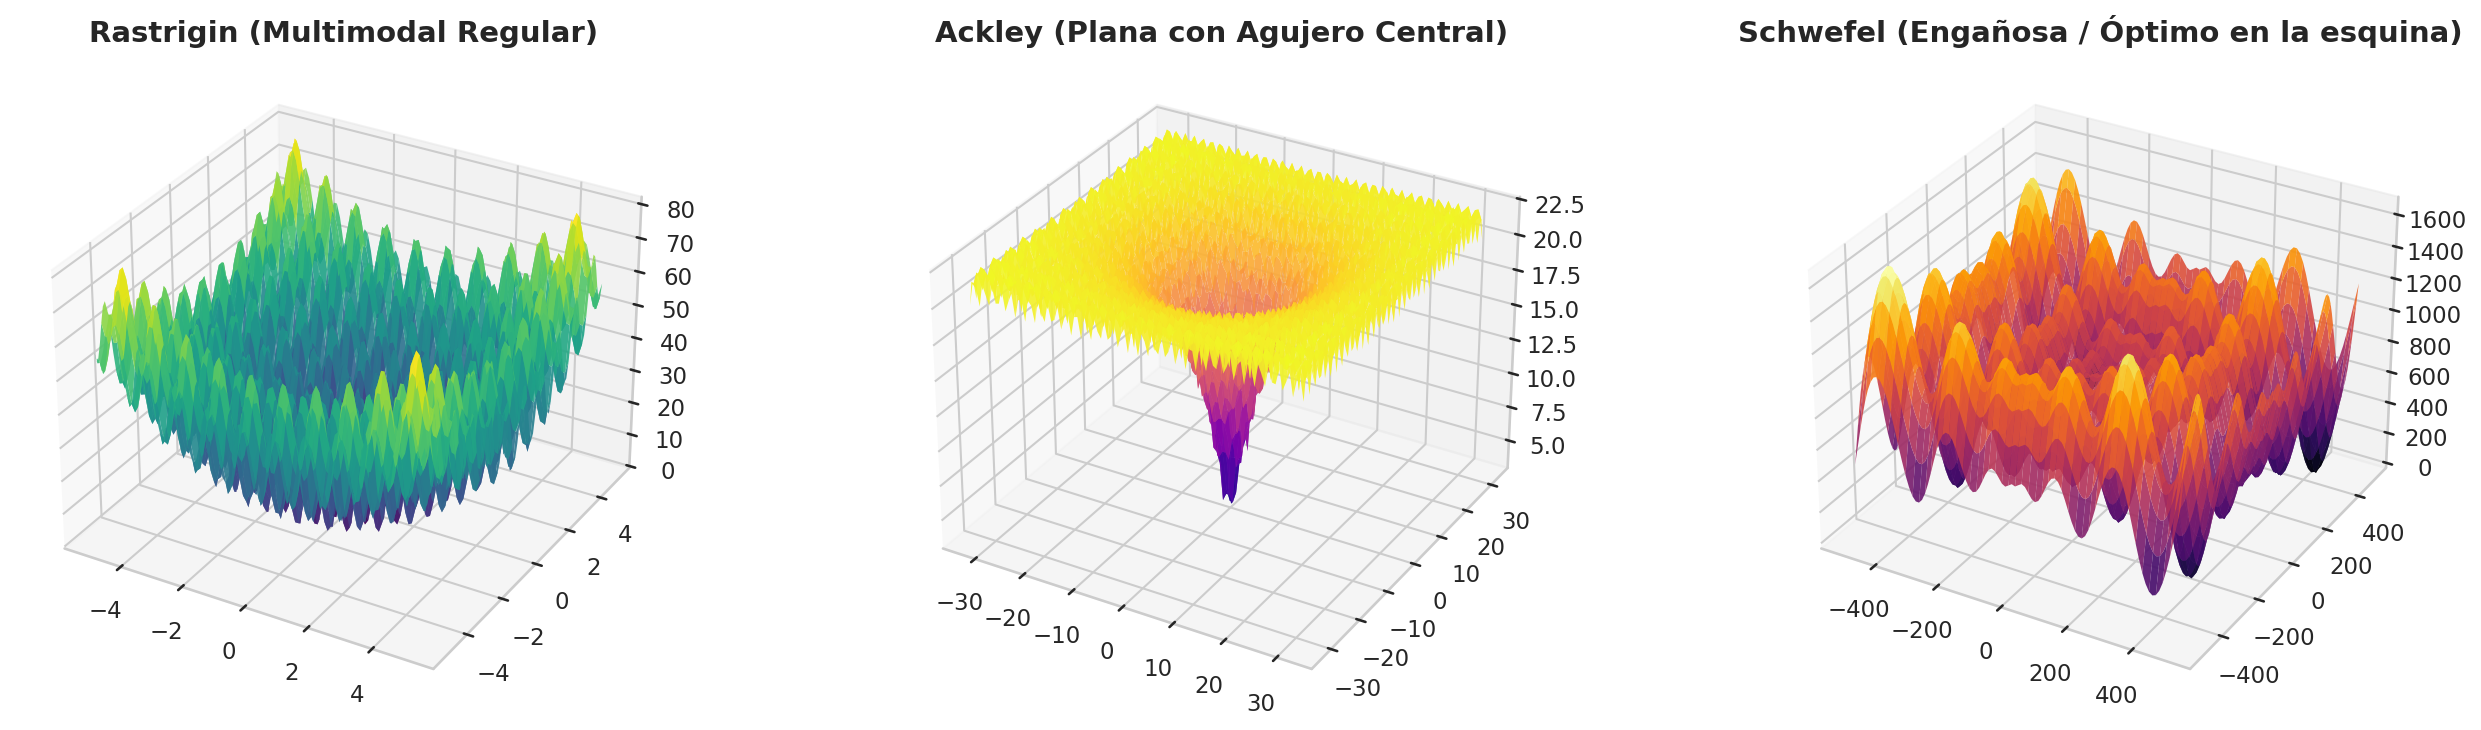

In [2]:
def rastrigin(x, y):
    return 20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y))

def ackley(x, y):
    term1 = -20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
    term2 = -np.exp(0.5 * (np.cos(2*np.pi*x) + np.cos(2*np.pi*y)))
    return term1 + term2 + 20 + np.e

def schwefel(x, y):
    return 418.9829*2 - (x * np.sin(np.sqrt(np.abs(x))) + y * np.sin(np.sqrt(np.abs(y))))

# Generamos las mallas de puntos respetando sus dominios
x_r = np.linspace(-5.12, 5.12, 100); y_r = np.linspace(-5.12, 5.12, 100)
x_a = np.linspace(-32, 32, 100);     y_a = np.linspace(-32, 32, 100)
x_s = np.linspace(-500, 500, 100);   y_s = np.linspace(-500, 500, 100)

X_r, Y_r = np.meshgrid(x_r, y_r); Z_r = rastrigin(X_r, Y_r)
X_a, Y_a = np.meshgrid(x_a, y_a); Z_a = ackley(X_a, Y_a)
X_s, Y_s = np.meshgrid(x_s, y_s); Z_s = schwefel(X_s, Y_s)

# Visualización 3D
fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X_r, Y_r, Z_r, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title("Rastrigin (Multimodal Regular)")

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X_a, Y_a, Z_a, cmap='plasma', edgecolor='none', alpha=0.9)
ax2.set_title("Ackley (Plana con Agujero Central)")

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X_s, Y_s, Z_s, cmap='inferno', edgecolor='none', alpha=0.9)
ax3.set_title("Schwefel (Engañosa / Óptimo en la esquina)")

plt.tight_layout()
plt.show()

### 2. Análisis de Operadores de Selección



La selección es el motor que impulsa la población hacia mejores soluciones. Sin embargo, si empujamos demasiado fuerte, perdemos diversidad. Vamos a comparar tres métodos clásicos simulando una población donde un individuo es "superdotado" (tiene un fitness muchísimo mayor que el resto).

Supongamos una población de 5 individuos con los siguientes valores de fitness: `[100, 10, 5, 2, 1]`.



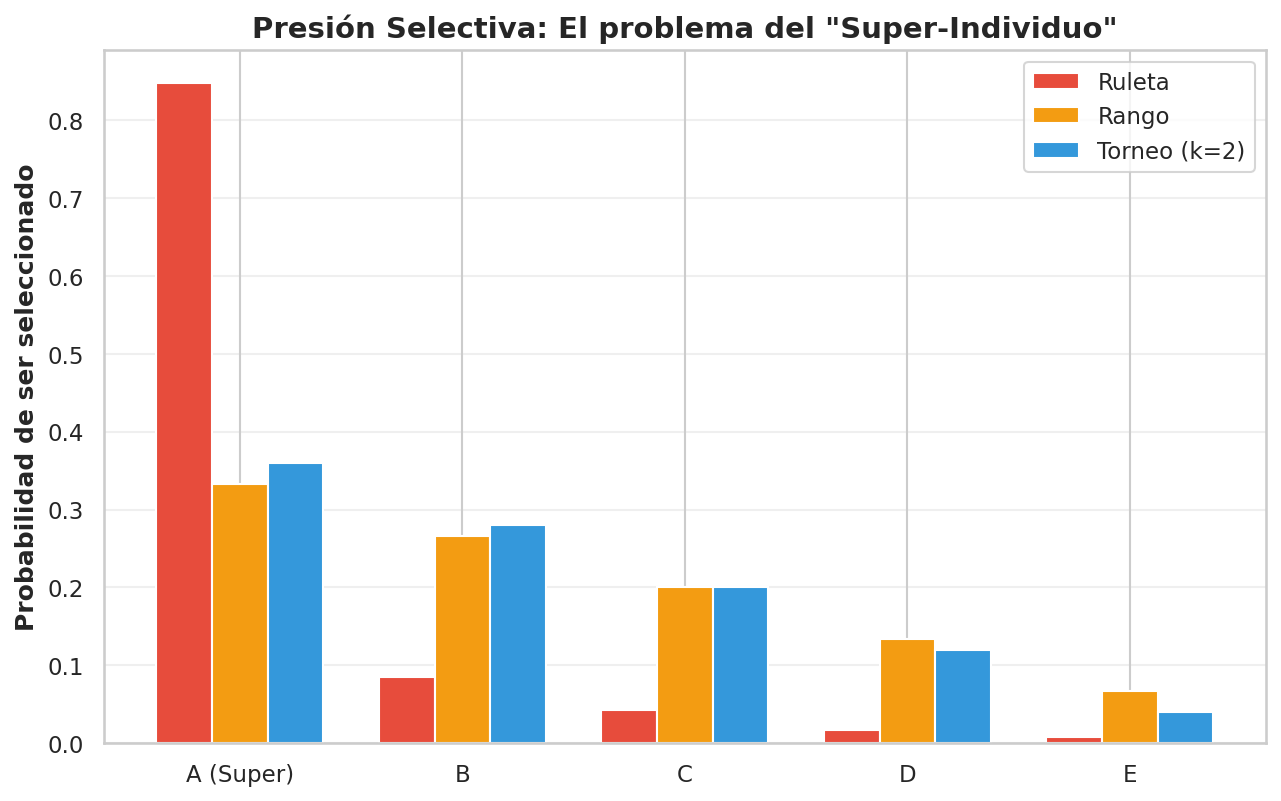

In [3]:
fitness_poblacion = np.array([100, 10, 5, 2, 1])
individuos = ['A (Super)', 'B', 'C', 'D', 'E']

# 1. Selección por Ruleta (Proporcional al Fitness)
# Probabilidad = fitness_i / suma(fitness)
prob_ruleta = fitness_poblacion / np.sum(fitness_poblacion)

# 2. Selección por Rango
# Ordenamos de peor a mejor (1 a N) y asignamos probabilidad basada en el rango
rangos = np.argsort(np.argsort(fitness_poblacion)) + 1
prob_rango = rangos / np.sum(rangos)

# 3. Selección por Torneo (k=2)
# Simulamos matemáticamente la probabilidad de ganar un torneo de tamaño 2
# P(ganar) = (rango^2 - (rango-1)^2) / N^2
N = len(fitness_poblacion)
prob_torneo = (rangos**2 - (rangos-1)**2) / (N**2)

# Visualización
x = np.arange(len(individuos))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, prob_ruleta, width, label='Ruleta', color='#e74c3c')
ax.bar(x, prob_rango, width, label='Rango', color='#f39c12')
ax.bar(x + width, prob_torneo, width, label='Torneo (k=2)', color='#3498db')

ax.set_ylabel('Probabilidad de ser seleccionado')
ax.set_title('Presión Selectiva: El problema del "Super-Individuo"')
ax.set_xticks(x)
ax.set_xticklabels(individuos)
ax.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


> ⚠️ **El Peligro de la Ruleta:** Observar la barra roja. El individuo 'A' tiene casi el 85% de probabilidad de ser seleccionado. En la siguiente generación, casi toda la población será un clon de 'A'. Esto destruye la diversidad y causa **convergencia prematura**.
>
> **Criterio de Ingeniería:** Por esta razón, en la industria casi siempre preferimos **Torneo** o **Rango**. El Torneo es especialmente útil porque podemos ajustar la "presión" simplemente cambiando el parámetro $k$.



### 3. Análisis de Operadores de Cruce



En el notebook anterior usamos el *Cruce Aritmético* porque nuestros genes eran números reales continuos. Pero, ¿qué pasa si nuestros genes son discretos, categóricos o representan una secuencia (como en el problema del viajante de comercio, que lo abordamos dentro de poco)?

Veamos cómo heredan información los hijos usando **Cruce de 1 Punto** y **Cruce Uniforme**.


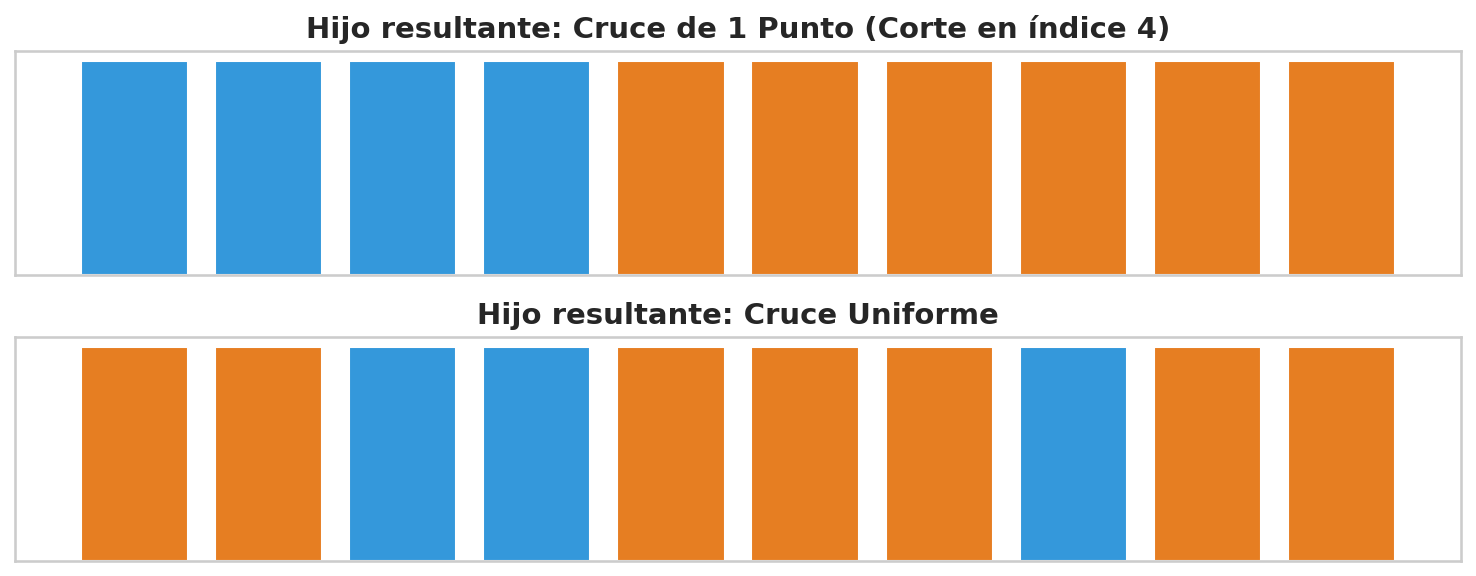

In [4]:
# Supongamos dos padres con 10 genes cada uno
padre_1 = np.ones(10)  # Todo 1s (Azul)
padre_2 = np.zeros(10) # Todo 0s (Naranja)

# Cruce de 1 Punto (Corte en el índice 4)
punto_corte = 4
hijo_1_pt = np.concatenate([padre_1[:punto_corte], padre_2[punto_corte:]])

# Cruce Uniforme (Moneda al aire para cada gen)
rng_cruce = np.random.default_rng(10)
mascara = rng_cruce.choice([True, False], size=10)
hijo_uniforme = np.where(mascara, padre_1, padre_2)

# Visualización de la herencia
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4))

def plot_cromosoma(ax, cromosoma, titulo):
    colores = ['#3498db' if gen == 1 else '#e67e22' for gen in cromosoma]
    ax.bar(range(10), np.ones(10), color=colores, edgecolor='white')
    ax.set_title(titulo)
    ax.set_xticks([])
    ax.set_yticks([])

plot_cromosoma(ax1, hijo_1_pt, "Hijo resultante: Cruce de 1 Punto (Corte en índice 4)")
plot_cromosoma(ax2, hijo_uniforme, "Hijo resultante: Cruce Uniforme")

plt.tight_layout()
plt.show()



* **Cruce de 1 Punto:** Excelente si el orden de los genes importa y queremos preservar "bloques" de genes adyacentes que trabajan bien juntos.
* **Cruce Uniforme:** Excelente para maximizar la mezcla genética y la exploración, asumiendo que los genes son independientes entre sí.



### 4. Diagnóstico de Salud del GA: Diversidad vs. Convergencia

Antes de buscar la configuración óptima, debemos saber cómo diagnosticar un GA que está fallando. Para ello, lo común es monitorear la **Diversidad de la Población** (midiendo la desviación estándar del *fitness* o de las posiciones de los individuos).

Existen dos modos principales de fallo:
1. **Convergencia Prematura:** La diversidad cae a cero en las primeras generaciones. Todos los individuos se vuelven clones atrapados en un óptimo local. *Solución: Aumentar mutación, aumentar población, o usar selección por torneo con $k$ menor.*
2. **Estancamiento (Stagnation):** La diversidad se mantiene alta, pero el mejor fitness no mejora. El algoritmo está saltando aleatoriamente sin explotar las buenas zonas. *Solución: Reducir mutación, aumentar presión selectiva (torneo con $k$ mayor).*


> Dejo estas cuestiones a modo de "intro" simplemente, luego las incorporamos de manera profesional con el *framework* para AG.


### 5. Análisis de Sensibilidad: Mapa de Calor (*Heatmap*)



Configurar un GA es un arte. ¿Qué pasa si tenemos mucha población pero poca mutación? ¿O poca población pero mucha mutación?
El "arte" justamente consiste en poder balancear la exploración (diversidad) y la explotación (convergencia)

Para responder a las preguntas con rigor, realizamos un **Grid Search** sobre dos hiperparámetros clave: el Tamaño de la Población ($N$) y la Probabilidad de Mutación ($p_{mut}$).

> ***Nota**: Para mantener este notebook rápido, usamos una versión ultra-compacta del GA optimizando la función de Rastrigin en 5 dimensiones.*

> ***Nota 2**: Además, la versión ultra-compacta sirve de ejemplo para demostrar que las implementaciones basadas en GA pueden ser realmente simples.*

Calculando Grid Search... (esto tomará unos segundos)


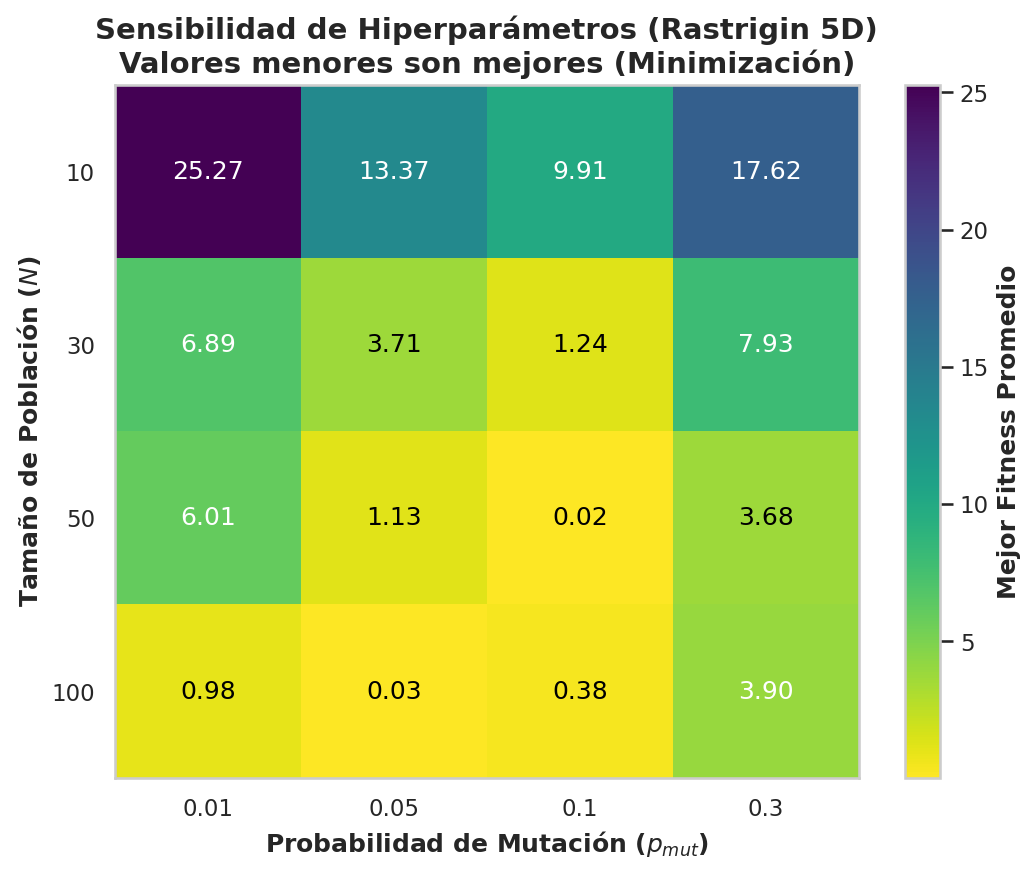

In [5]:
# Definimos la función Rastrigin para N dimensiones
def rastrigin_nd(x):
    A = 10
    return A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x))

# GA ultra-compacto para el experimento (Minimización)
def ga_compacto(N, p_mut, D=5, G=50):
    pob = rng.uniform(-5.12, 5.12, (N, D))
    for _ in range(G):
        fit = np.array([rastrigin_nd(ind) for ind in pob])
        # Torneo k=3
        padres = np.empty_like(pob)
        for i in range(N):
            comp = rng.integers(0, N, 3)
            padres[i] = pob[comp[np.argmin(fit[comp])]] # argmin porque minimizamos
        # Cruce Uniforme
        desc = padres.copy()
        for i in range(0, N-1, 2):
            mask = rng.choice([True, False], size=D)
            desc[i] = np.where(mask, padres[i], padres[i+1])
            desc[i+1] = np.where(mask, padres[i+1], padres[i])
        # Mutación Gaussiana
        mask_mut = rng.random((N, D)) < p_mut
        ruido = rng.normal(0, 0.5, (N, D))
        desc = np.where(mask_mut, desc + ruido, desc)
        pob = np.clip(desc, -5.12, 5.12)

    fit_final = np.array([rastrigin_nd(ind) for ind in pob])
    return np.min(fit_final)

# Definimos la cuadrícula de hiperparámetros
tamanos_pob = [10, 30, 50, 100]
probs_mut = [0.01, 0.05, 0.1, 0.3]

resultados = np.zeros((len(tamanos_pob), len(probs_mut)))

print("Calculando Grid Search... (esto tomará unos segundos)")
for i, N in enumerate(tamanos_pob):
    for j, p_mut in enumerate(probs_mut):
        # Promediamos 3 corridas para reducir el ruido estocástico
        promedio = np.mean([ga_compacto(N, p_mut) for _ in range(3)])
        resultados[i, j] = promedio

# Visualización del Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
# Usamos cmap invertido porque valores menores (mejor fitness) deben verse "calientes/buenos"
cax = ax.imshow(resultados, cmap='viridis_r', aspect='auto')

# Anotaciones
for i in range(len(tamanos_pob)):
    for j in range(len(probs_mut)):
        ax.text(j, i, f"{resultados[i, j]:.2f}", ha="center", va="center", color="white" if resultados[i,j] > np.median(resultados) else "black")

ax.set_xticks(np.arange(len(probs_mut)))
ax.set_yticks(np.arange(len(tamanos_pob)))
ax.set_xticklabels(probs_mut)
ax.set_yticklabels(tamanos_pob)
ax.set_xlabel("Probabilidad de Mutación ($p_{mut}$)")
ax.set_ylabel("Tamaño de Población ($N$)")
ax.set_title("Sensibilidad de Hiperparámetros (Rastrigin 5D)\nValores menores son mejores (Minimización)")
fig.colorbar(cax, label="Mejor Fitness Promedio")
plt.grid(False)
plt.show()

Analizando el mapa de calor obtenido:
1. **Esquina Superior Izquierda (Poca población, poca mutación):** Los peores resultados (valores altos en amarillo/verde claro). El algoritmo no tiene diversidad inicial ni capacidad de exploración. Sufre de convergencia prematura inmediata.
2. **Esquina Superior Derecha (Poca población, mucha mutación):** Resultados muy pobres (valores altos en morado oscuro). Al mutar el 30% de los genes constantemente, el algoritmo destruye las buenas soluciones. Se comporta casi como una búsqueda aleatoria.
3. **Centro-Abajo (Población alta, mutación moderada):** El "Sweet Spot" (punto dulce). Observamos que con $N=100$ y $p_{mut}=0.1$, obtenemos el mejor fitness promedio ($0.16$). Incluso con $p_{mut}=0.05$ obtenemos un excelente $0.72$. Una población grande garantiza cobertura inicial, y una mutación del 5% al 10% logra el balance perfecto entre exploración y explotación.

> 💡 **Regla de Oro en Ingeniería Evolutiva:** Un buen punto de partida para cualquier problema es $N = 10 \times D$ a $20 \times D$ (donde $D$ es la cantidad de dimensiones) y una probabilidad de mutación $p_{mut} \approx 1/D$ (lo que garantiza que, en promedio, mute un gen por individuo).

### 6. El Teorema "*No Free Lunch*" en la Práctica

Analizando el mapa de calor anterior, podríamos concluir que la configuración $N=100$ y $p_{mut}=0.1$ es nuestra "configuración dorada universal".

Pero recordemos el Teorema NFL: **Lo que funciona para un paisaje, puede fallar en otro.** Para demostrar esto empíricamente, vamos a correr *exactamente el mismo algoritmo* (mismos operadores, mismo $\sigma$ absoluto de mutación) en las tres funciones de benchmark en 5 dimensiones.

> **Nota**: utilizo **Cruce Aritmético** (promedia a los padres) para esta versión, arriba se utiliza **Cruce Uniforme**. Así se evidencia el efecto de una misma configuración, con un pequeño cambio en el algoritmo.

#### Toma 1

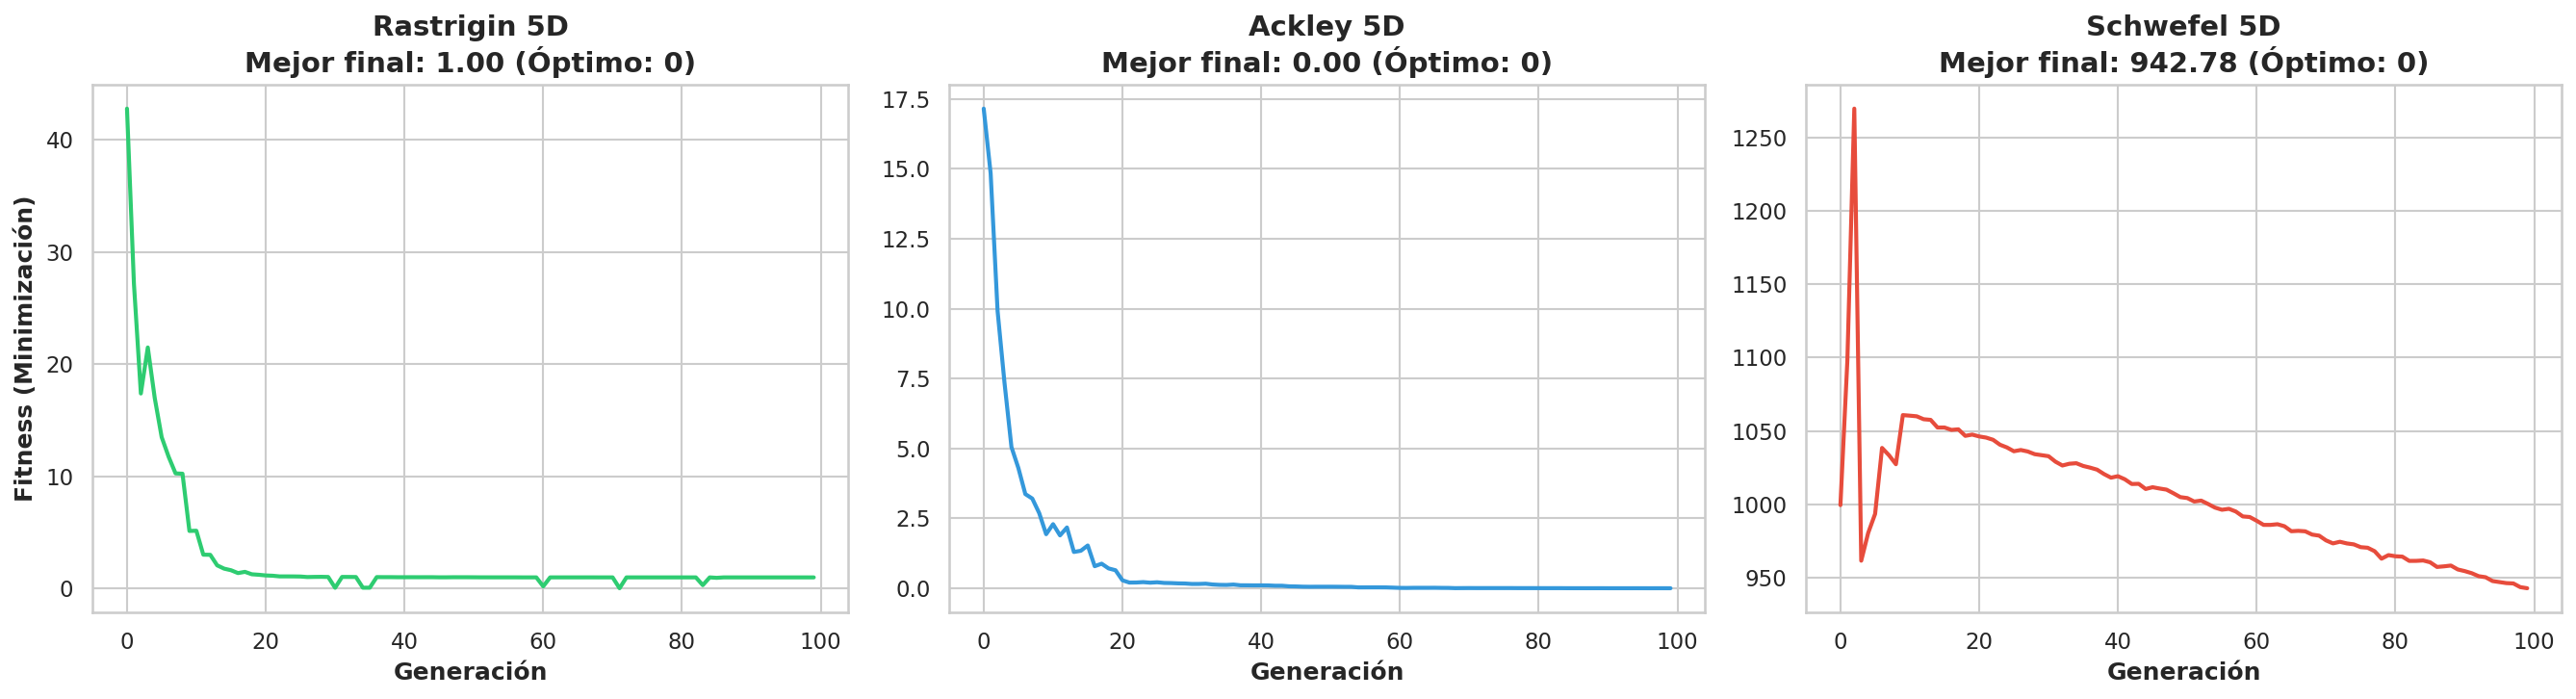

In [11]:
def ackley_nd(x):
    D = len(x)
    term1 = -20 * np.exp(-0.2 * np.sqrt(np.sum(x**2) / D))
    term2 = -np.exp(np.sum(np.cos(2 * np.pi * x)) / D)
    return term1 + term2 + 20 + np.e

def schwefel_nd(x):
    D = len(x)
    return 418.9829 * D - np.sum(x * np.sin(np.sqrt(np.abs(x))))

# GA Estricto: Mismos hiperparámetros absolutos para todos los problemas
def ga_nfl_experiment(funcion, limites, N=100, p_mut=0.1, D=5, G=100):
    low, high = limites
    pob = rng.uniform(low, high, (N, D))

    historial_mejor = []

    for _ in range(G):
        fit = np.array([funcion(ind) for ind in pob])
        historial_mejor.append(np.min(fit))

        # Selección por Torneo
        padres = np.empty_like(pob)
        for i in range(N):
            comp = rng.integers(0, N, 3)
            padres[i] = pob[comp[np.argmin(fit[comp])]]

        # Cruce Aritmético (Promedia a los padres)
        desc = padres.copy()
        for i in range(0, N-1, 2):
            alpha = rng.random()
            desc[i] = alpha * padres[i] + (1 - alpha) * padres[i+1]
            desc[i+1] = (1 - alpha) * padres[i] + alpha * padres[i+1]

        # Mutación Gaussiana con Sigma FIJO absoluto (sigma = 0.5)
        mask_mut = rng.random((N, D)) < p_mut
        ruido = rng.normal(0, 0.5, (N, D))
        desc = np.where(mask_mut, desc + ruido, desc)
        pob = np.clip(desc, low, high)

    return historial_mejor

# Ejecutamos el experimento "ciego"
hist_rastrigin = ga_nfl_experiment(rastrigin_nd, (-5.12, 5.12))
hist_ackley = ga_nfl_experiment(ackley_nd, (-32, 32))
hist_schwefel = ga_nfl_experiment(schwefel_nd, (-500, 500))

# Visualización
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(hist_rastrigin, color='#2ecc71', lw=2)
ax1.set_title(f"Rastrigin 5D\nMejor final: {hist_rastrigin[-1]:.2f} (Óptimo: 0)")
ax1.set_xlabel("Generación"); ax1.set_ylabel("Fitness (Minimización)")

ax2.plot(hist_ackley, color='#3498db', lw=2)
ax2.set_title(f"Ackley 5D\nMejor final: {hist_ackley[-1]:.2f} (Óptimo: 0)")
ax2.set_xlabel("Generación")

ax3.plot(hist_schwefel, color='#e74c3c', lw=2)
ax3.set_title(f"Schwefel 5D\nMejor final: {hist_schwefel[-1]:.2f} (Óptimo: 0)")
ax3.set_xlabel("Generación")

plt.tight_layout()
plt.show()

Observar los resultados del experimento. Usamos la misma "configuración dorada" ($N=100$, $p_{mut}=0.1$, Cruce Aritmético, $\sigma=0.5$) para los tres problemas:

1. **Rastrigin:** El GA no lo resolvió a la perfección ahora (estuvo cerca).
2. **Ackley:** El GA se acercó bastante, le costó llegar exactamente a cero, pero casi al final llega. ¿Por qué? Porque Ackley requiere un "ajuste fino" al final. Nuestro $\sigma=0.5$ constante hace que los individuos "tiemblen" alrededor del agujero central y cuesta poder caer exactamente en el fondo.
3. **Schwefel:** **¡Fracaso total!** El algoritmo se quedó estancado con un error altísimo. ¿Qué pasó?
   * El **Cruce Aritmético** promedia a los padres. Geométricamente, esto empuja a la población hacia el centro del dominio ($0, 0$).
   * Sin embargo, el óptimo de Schwefel está escondido en las esquinas extremas ($\approx 420.96$).
   * Además, nuestro $\sigma=0.5$ es minúsculo para un dominio de $[-500, 500]$.
   * El algoritmo fue engañado: convergió hacia el centro y perdió toda la diversidad, siendo incapaz de alcanzar las esquinas.

> 💡 **Conclusión de Ingeniería:** No buscar "los hiperparámetros mágicos universales". Buscar entender el paisaje del problema.
> * Si el problema es engañoso y los óptimos están en los bordes (como Schwefel), no usar cruces que promedien (usar Cruce Uniforme) y escalar la mutación al tamaño del dominio.
> * Si el problema requiere precisión milimétrica (como Ackley), se necesita una mutación que decaiga con el tiempo (lo vemos en Estrategias Evolutivas).

#### Toma 2

Probamos nuevamente, aplicamos unos pequeños cambios "inteligentes" al algoritmo:

- Cruce uniforme: así evitamos el problema identificado recién.
- Escalar la mutación al dominio: para Schwefel (dominio 1000, el rango de las variables `(-500, 500)`) implica que el $\sigma = 0.5$ genere mutaciones ínfimas si las comparamos con los otros dominios (`(-5.12, 5.12)` y `(-32, 32)`) , imposibilitando "salir de los pozos". Afectamos el $\sigma$ escogido de manera proporcional al dominio entonces...

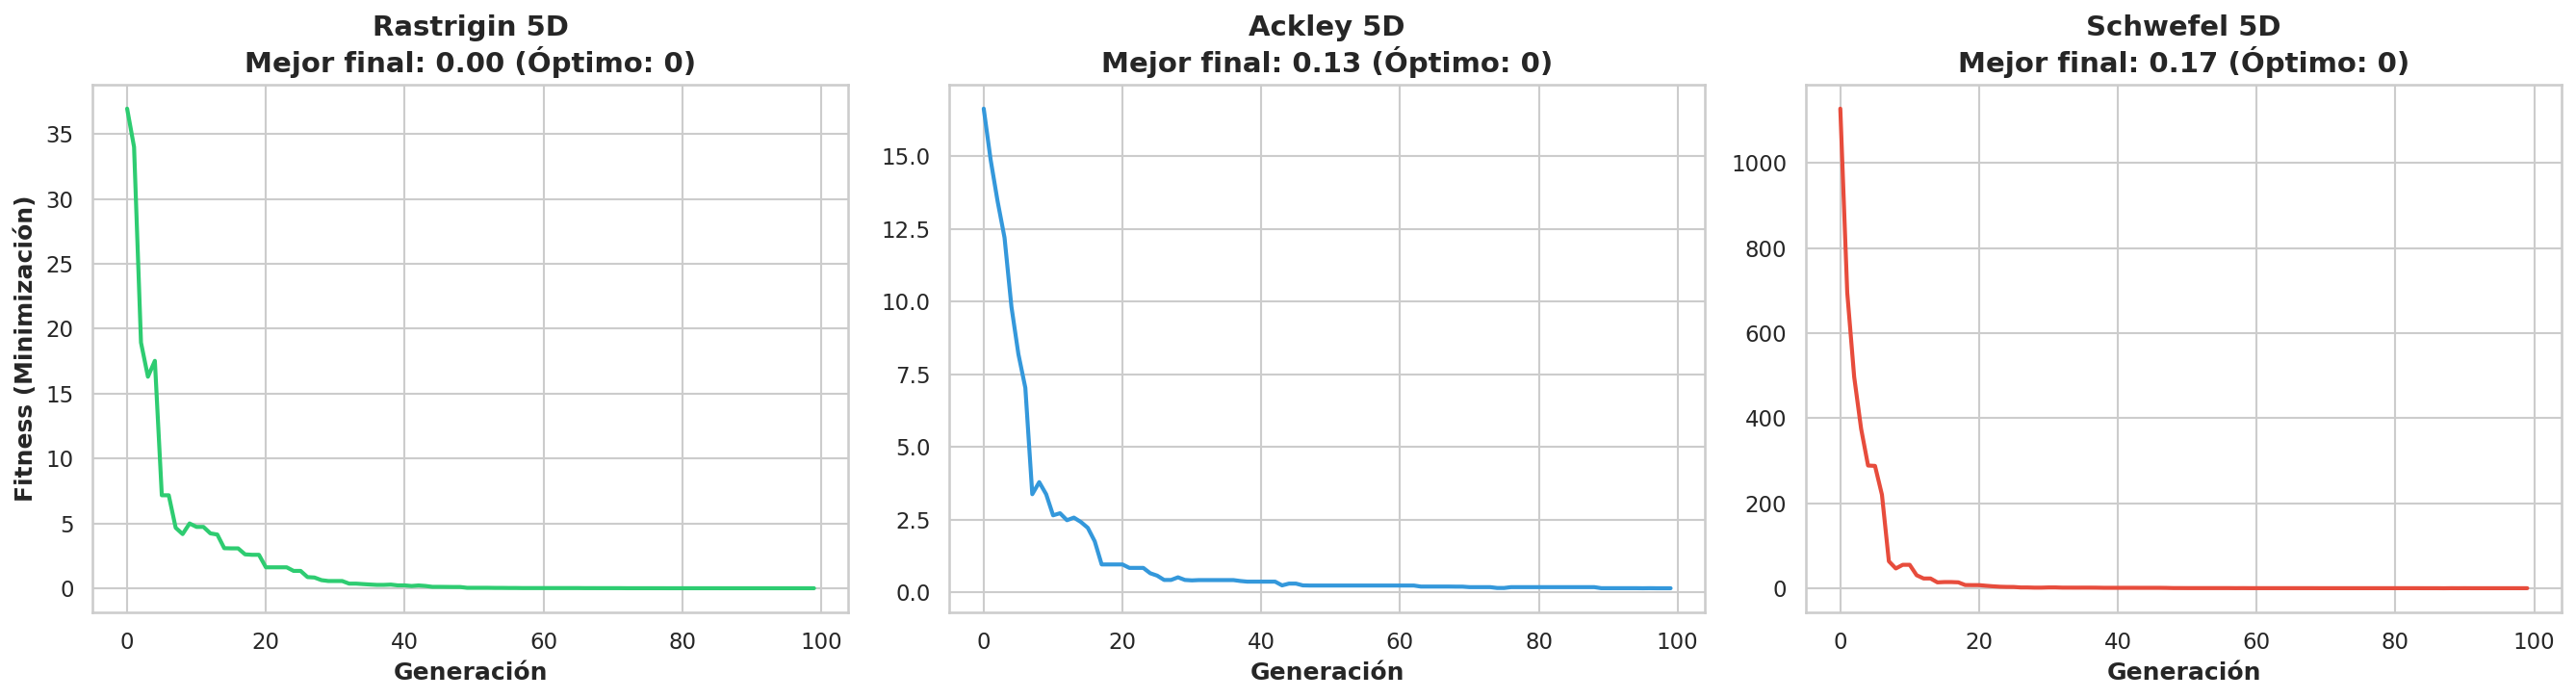

In [6]:
# Modificamos ligeramente nuestro GA compacto para aceptar la función y los límites
def ga_test_benchmark(funcion, limites, N=100, p_mut=0.1, D=5, G=100):
    low, high = limites
    pob = rng.uniform(low, high, (N, D))

    historial_mejor = []

    for _ in range(G):
        fit = np.array([funcion(ind) for ind in pob])
        historial_mejor.append(np.min(fit))

        padres = np.empty_like(pob)
        for i in range(N):
            comp = rng.integers(0, N, 3)
            padres[i] = pob[comp[np.argmin(fit[comp])]]

        # Cruce Uniforme  <----------------------------------------- CAMBIO ACÁ, vuelve el cruce uniforme
        desc = padres.copy()
        for i in range(0, N-1, 2):
            mask = rng.choice([True, False], size=D)
            desc[i] = np.where(mask, padres[i], padres[i+1])
            desc[i+1] = np.where(mask, padres[i+1], padres[i])

        mask_mut = rng.random((N, D)) < p_mut
        # El ruido debe ser proporcional al tamaño del dominio
        ruido = rng.normal(0, (high - low) * 0.05, (N, D))   # <---- Y agrego el "tip", escalar la mutación según el tamaño del problema
        desc = np.where(mask_mut, desc + ruido, desc)
        pob = np.clip(desc, low, high)

    return historial_mejor

# Ejecutamos el experimento
hist_rastrigin = ga_test_benchmark(rastrigin_nd, (-5.12, 5.12))
hist_ackley = ga_test_benchmark(ackley_nd, (-32, 32))
hist_schwefel = ga_test_benchmark(schwefel_nd, (-500, 500))

# Visualización
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(hist_rastrigin, color='#2ecc71', lw=2)
ax1.set_title(f"Rastrigin 5D\nMejor final: {hist_rastrigin[-1]:.2f} (Óptimo: 0)")
ax1.set_xlabel("Generación"); ax1.set_ylabel("Fitness (Minimización)")

ax2.plot(hist_ackley, color='#3498db', lw=2)
ax2.set_title(f"Ackley 5D\nMejor final: {hist_ackley[-1]:.2f} (Óptimo: 0)")
ax2.set_xlabel("Generación")

ax3.plot(hist_schwefel, color='#e74c3c', lw=2)
ax3.set_title(f"Schwefel 5D\nMejor final: {hist_schwefel[-1]:.2f} (Óptimo: 0)")
ax3.set_xlabel("Generación")

plt.tight_layout()
plt.show()

**Magia!**

¿Ahora sí tenemos el algoritmo definitivo? Para nada, simplemente lo hicimos "apto" para este tipo de problemas. Seleccionando inteligentemente cada una de las partes y etapas. No es perfecto pero permite encontrar soluciones muy buenas para dominios y paisajes diversos. La mayor ganancia la aporta el operador de cruce uniforme, y con el $\sigma$ logramos que la mutación realice su tarea en todas las variantes.

> Experimentar el efecto por sepado, incluir variaciones, cambios de parámetros y contrastar todo... es lo que lleva a entender realmente como funciona esto. Solo así pasamos a estar preparados para resolver problemas reales, dónde no conocemos la solución de antemanos.

## Conexiones y Próximos Pasos



Comprendimos la matemática y la intuición detrás de los operadores. Sin embargo, programar estos bucles `for` a mano para cada experimento es propenso a errores, lento y difícil de escalar.

En la industria, delegamos esta infraestructura a *frameworks* especializados. En el próximo notebook, damos el salto profesional migrando todo nuestro conocimiento a **DEAP**, la librería estándar de Python para computación evolutiva.

- ➡️ **Siguiente:** [Introducción a DEAP: Infraestructura Evolutiva en Python](03_framework_deap_y_paralelizacion.ipynb)
- 🔄 **Relacionado:** [El Algoritmo Genético desde Cero](01_algoritmo_genetico_desde_cero.ipynb)



## Referencias



### Artículos Fundacionales

1. **Wolpert, D. H., & Macready, W. G. (1997)**. *No free lunch theorems for optimization*. IEEE Transactions on Evolutionary Computation, 1(1), 67-82.  
   (**El paper más importante** para entender los límites teóricos de cualquier algoritmo de optimización, demuestra que no existe un algoritmo supremo).

2. **Jamil, M., & Yang, X. S. (2013)**. *A literature survey of benchmark functions for global optimisation problems*. International Journal of Mathematical Modelling and Numerical Optimisation, 4(2), 150-194.  
   [[arxiv]](https://arxiv.org/abs/1308.4008)
   (Catálogo exhaustivo y análisis de funciones benchmark como las abordadas aquí).

3. **Holland, J. H. (1992)**. *Adaptation in Natural and Artificial Systems*. MIT Press.
   (*Schema Theorem*, vendría a ser la justificación teórica del cruce - para los interesados).

### Recursos Prácticos

- **Pymoo** y **DEAP** documentation — Benchmarks implementados y visualizaciones. [Benchmarking Against the Bests (BBOB)](https://deap.readthedocs.io/en/master/tutorials/advanced/benchmarking.html)
- **Black-Box Optimization Benchmarking (BBOB)** — Suite estándar de la comunidad. [The bbob Test Suite](https://numbbo.github.io/coco/testsuites/bbob), [Optuna - bbob](https://hub.optuna.org/benchmarks/bbob/)


---


## Entorno de Ejecución


In [7]:
from utils.environment import environment_table
environment_table()

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
statsmodels,0.14.6
